# Model Training for eBay Price Prediction

This notebook loads the processed eBay listings dataset and trains regression models to predict `price_log`.

Steps:
1. Load processed data and feature metadata
2. Select model features
3. Train baseline regressors
4. Evaluate performance on train/test splits
5. Visualize predictions and residuals


In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [8]:
# Load processed data and feature metadata
processed_dir = Path('../datasets/processed')
train_path = processed_dir / 'ebay_train_processed.csv'
test_path = processed_dir / 'ebay_test_processed.csv'
feature_info_path = processed_dir / 'feature_info.json'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
with open(feature_info_path, 'r') as f:
    feature_info = json.load(f)

print(f'Train samples: {len(train_df):,}')
print(f'Test samples: {len(test_df):,}')
print(f'Available numeric features: {len(feature_info["numeric_features"]):,}')


Train samples: 5,406
Test samples: 1,352
Available numeric features: 26


In [9]:
# Select features for modeling
scaled_features = feature_info['scaled_features']
additional_features = ['category_encoded', 'brand_encoded', 'group_count', 'condition_bucket']
feature_columns = scaled_features + additional_features
target_column = 'price_log'

print('Using features:')
print(feature_columns)

X_train = train_df[feature_columns]
y_train = train_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]


Using features:
['title_length_scaled', 'seller_feedback_score_scaled', 'seller_feedback_pct_scaled', 'group_median_price_scaled', 'group_mean_price_scaled', 'group_std_price_scaled', 'title_emb_0_scaled', 'title_emb_1_scaled', 'title_emb_2_scaled', 'title_emb_3_scaled', 'title_emb_4_scaled', 'title_emb_5_scaled', 'title_emb_6_scaled', 'title_emb_7_scaled', 'title_emb_8_scaled', 'title_emb_9_scaled', 'title_emb_10_scaled', 'title_emb_11_scaled', 'title_emb_12_scaled', 'title_emb_13_scaled', 'title_emb_14_scaled', 'title_emb_15_scaled', 'category_encoded', 'brand_encoded', 'group_count', 'condition_bucket']


In [10]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'model': name,
        'train_rmse': mean_squared_error(y_train, y_train_pred),
        'test_rmse': mean_squared_error(y_test, y_test_pred),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred),
    }
    return metrics, y_test_pred

model_results = []

linear_model = LinearRegression()
model_results.append(evaluate_model('LinearRegression', linear_model, X_train, y_train, X_test, y_test))

ridge_model = Ridge(random_state=42)
model_results.append(evaluate_model('Ridge', ridge_model, X_train, y_train, X_test, y_test))

rf_model = RandomForestRegressor(random_state=42, n_estimators=150, n_jobs=-1)
model_results.append(evaluate_model('RandomForest', rf_model, X_train, y_train, X_test, y_test))

try:
    from xgboost import XGBRegressor
    xgb_model = XGBRegressor(n_estimators=150, random_state=42, verbosity=0, n_jobs=-1)
    model_results.append(evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test))
except ImportError:
    print('XGBoost not installed; skipping XGBoost model.')


In [11]:
# Display evaluation results
results_df = pd.DataFrame([metrics for metrics, _ in model_results])
results_df = results_df[['model', 'train_rmse', 'test_rmse', 'train_mae', 'test_mae', 'train_r2', 'test_r2']]
results_df.loc[:, ['train_rmse', 'test_rmse', 'train_mae']] = results_df[['train_rmse', 'test_rmse', 'train_mae']].round(4)
results_df.loc[:, ['train_r2', 'test_r2']] = results_df[['train_r2', 'test_r2']].round(4)
results_df


,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,LinearRegression,0.8294,0.8390,0.7074,0.709230,0.6309,0.6469
1,Ridge,0.8409,0.8539,0.7150,0.718227,0.6258,0.6407
2,RandomForest,0.0602,0.4230,0.1710,0.449423,0.9732,0.8220
3,XGBoost,0.0226,0.4777,0.1098,0.479764,0.9899,0.7990


Best model by test RMSE: {'model': 'RandomForest', 'train_rmse': 0.06024045632892119, 'test_rmse': 0.42297755658175035, 'train_mae': 0.17103896017962059, 'test_mae': 0.4494230861901069, 'train_r2': 0.9731935850400455, 'test_r2': 0.8220073369535162}


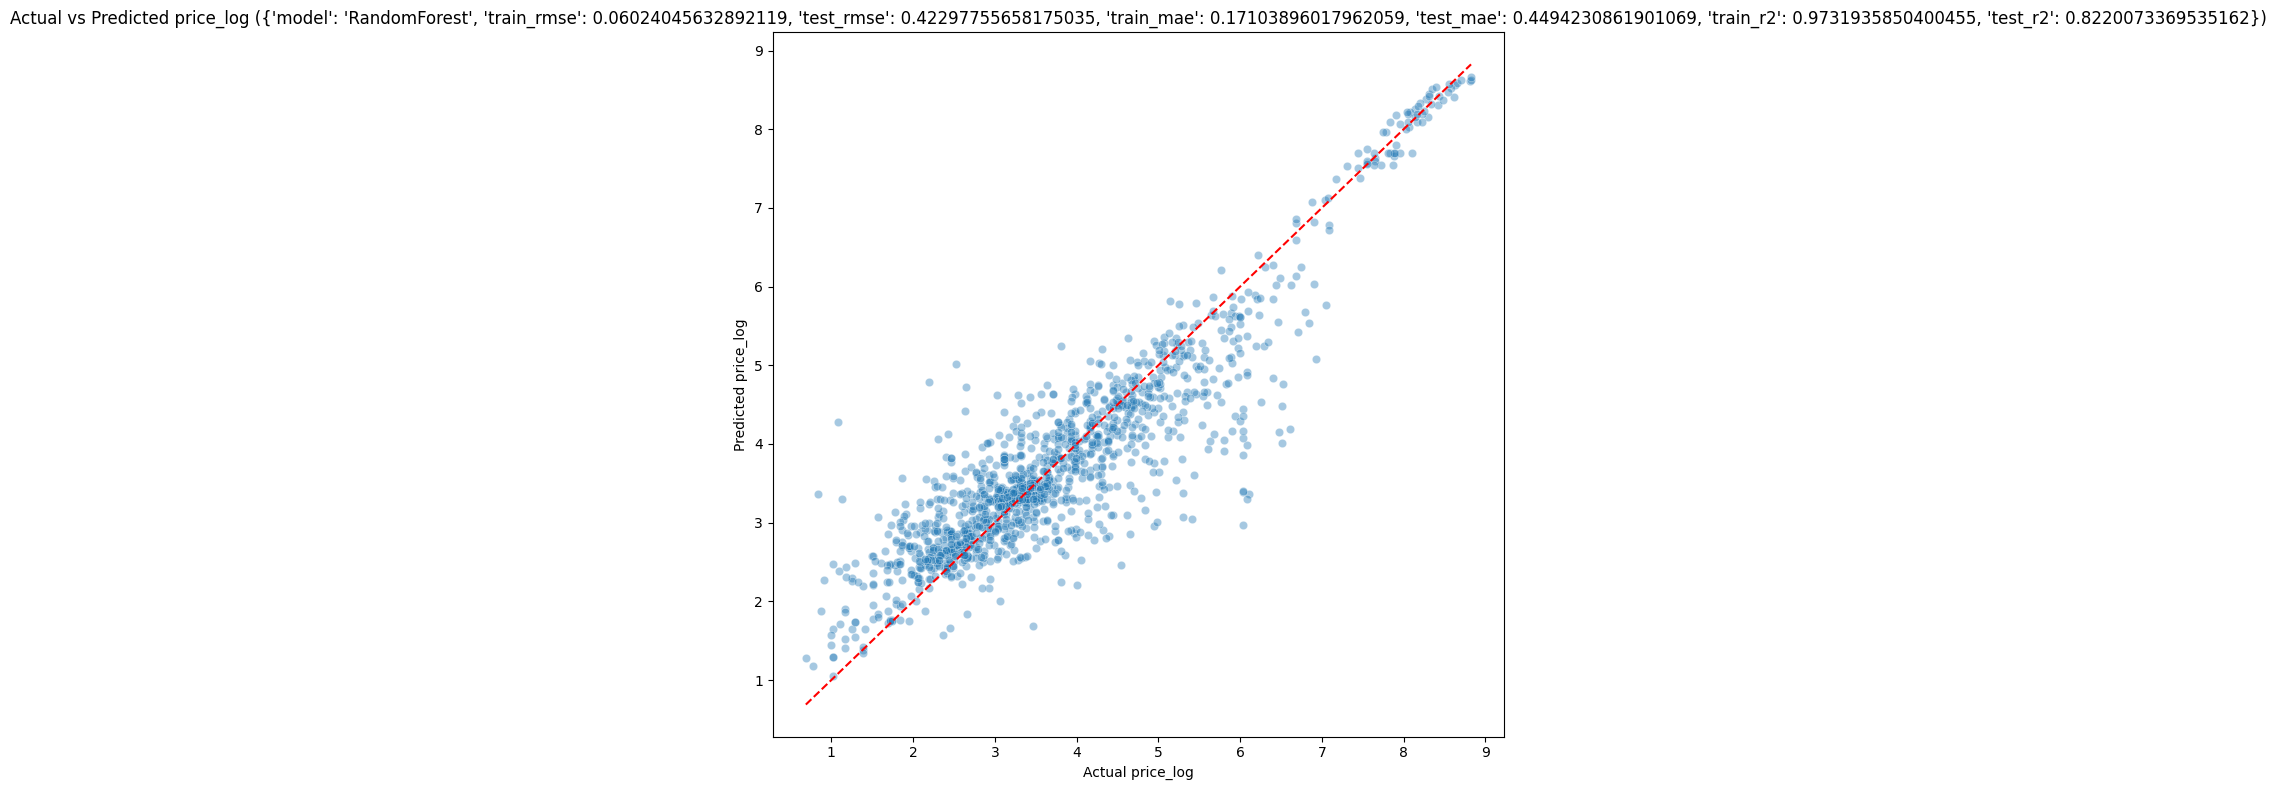

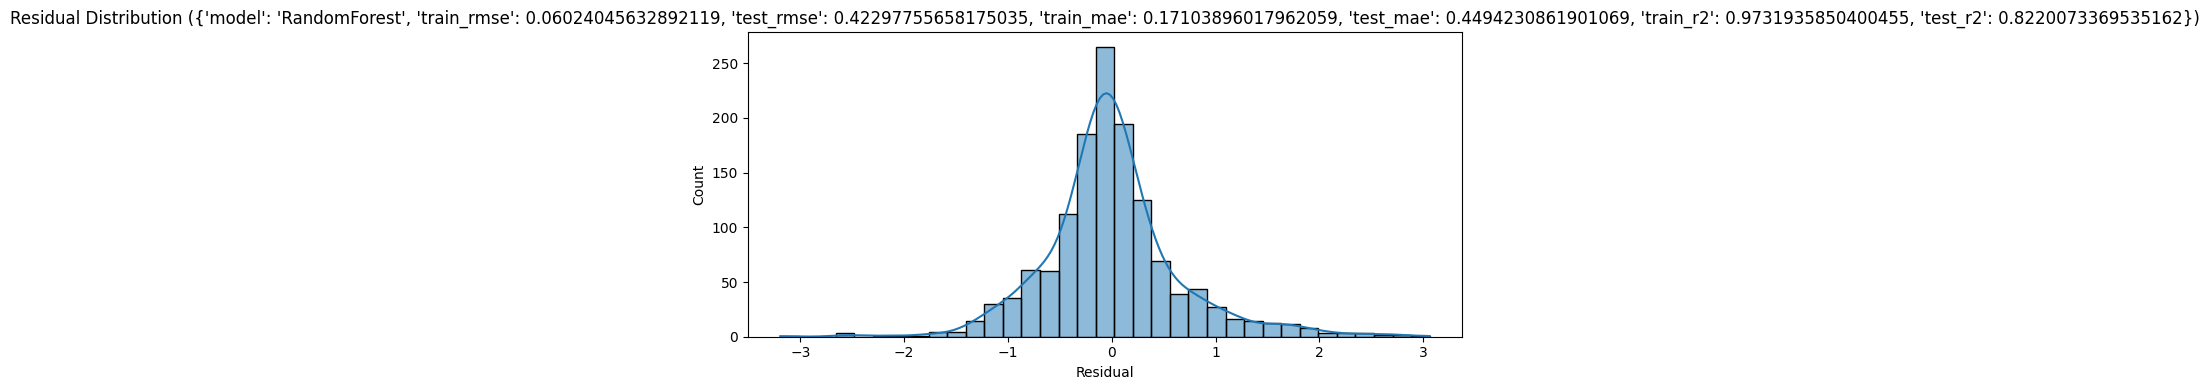

In [12]:
# Visualize predictions for the best model on the test set
best_model_name, best_model_pred = sorted(model_results, key=lambda item: item[0]['test_rmse'])[0]
print(f'Best model by test RMSE: {best_model_name}')

y_pred = best_model_pred

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual price_log')
plt.ylabel('Predicted price_log')
plt.title(f'Actual vs Predicted price_log ({best_model_name})')
plt.tight_layout()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=35)
plt.title(f'Residual Distribution ({best_model_name})')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()


## Notes

- `price_log` is the target variable to reduce skew and improve regression behavior.
- The notebook evaluates a small baseline model set and uses the processed feature set from `datasets/processed/feature_info.json`.
- Next steps can include feature selection, hyperparameter tuning, and model stacking.
